# 03 — Model Evaluation

## Objective

This notebook evaluates the **final LightGBM demand-forecasting model** on a completely unseen future period.

The model predicts **daily unit sales for an item at a store** using product/store information, calendar variables, price and recent demand history.

The evaluation has two goals:

1. Measure overall predictive performance against a simple **lag-1 baseline**.
2. Understand both the model's strengths and the situations where its predictions become less reliable.

> **Important:** The test period is used only for final evaluation. It was not used to choose features, tune the model, or select the final model configuration.

## Final experimental setup

The final model was selected in `02_model_training.ipynb` after several controlled experiments. The main progression was:

- A lag-1 baseline established a simple benchmark.
- LightGBM substantially improved on that benchmark.
- Increasing model complexity from 31 → 64 → 128 leaves produced progressively better validation performance, with 128 leaves becoming the strongest configuration.
- Adding `lag_2` and `lag_3` produced a small but measurable additional improvement.
- A Poisson objective and a log-transformed target were tested but did not provide a meaningful improvement in the original sales-scale metrics.

The selected model was therefore **LightGBM with 128 leaves and the short-term lag features retained**.

## Load the evaluation data

The processed Parquet file contains the feature-engineered historical dataset. Because `lag_2` and `lag_3` were added during model experimentation after the Parquet file was originally created, they are reconstructed below so the evaluation data exactly matches the features expected by the saved final model.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

In [2]:
sales_model = pd.read_parquet(
    "../data/processed_sales.parquet"
)

print("Shape:", sales_model.shape)
print(
    "Date range:",
    sales_model["date"].min(),
    "→",
    sales_model["date"].max()
)

Shape: (58327370, 24)
Date range: 2011-02-26 00:00:00 → 2016-05-22 00:00:00


## Load the final model and feature definition

Using the saved feature list is important: it prevents the evaluation pipeline from accidentally using a different set or order of features than the model saw during training.

In [4]:
model = joblib.load(
    "../models/final_lightgbm_model.pkl"
)

feature_cols = joblib.load(
    "../models/final_feature_cols.pkl"
)

print("Model loaded.")
print("Number of features:", len(feature_cols))

Model loaded.
Number of features: 23


## Recreate the short-term lag features

The final model includes `lag_2` and `lag_3`. These features are calculated **within each item-store series** so that sales from one product/store combination can never leak into another.

In [6]:
# Recreate the two features used by the final model
sales_model = sales_model.sort_values(
    ["item_id", "store_id", "date"]
).reset_index(drop=True)

group = sales_model.groupby(
    ["item_id", "store_id"],
    sort=False
)["sales"]

sales_model["lag_2"] = group.shift(2).astype("float32")
sales_model["lag_3"] = group.shift(3).astype("float32")

print("lag_2 missing:", sales_model["lag_2"].isna().sum())
print("lag_3 missing:", sales_model["lag_3"].isna().sum())

lag_2 missing: 60980
lag_3 missing: 91470


## Define the untouched test period

The final test window is **2016-04-25 to 2016-05-22**. This is the final 28-day historical period available in the sales data.

In [7]:
test_mask = (
    (sales_model["date"] >= "2016-04-25") &
    (sales_model["date"] <= "2016-05-22")
)

X_test = sales_model.loc[
    test_mask,
    feature_cols
]

y_test = sales_model.loc[
    test_mask,
    "sales"
]

print("Test rows:", len(X_test))
print(
    "Test period:",
    sales_model.loc[test_mask, "date"].min(),
    "→",
    sales_model.loc[test_mask, "date"].max()
)

Test rows: 853720
Test period: 2016-04-25 00:00:00 → 2016-05-22 00:00:00


## Generate final test predictions

The saved model is now evaluated on data it has never seen during training or model selection.

In [9]:
# Generate predictions on the untouched test set
test_predictions = model.predict(X_test)

print("Predictions generated.")
print("Number of predictions:", len(test_predictions))
print("Minimum prediction:", test_predictions.min())
print("Maximum prediction:", test_predictions.max())

Predictions generated.
Number of predictions: 853720
Minimum prediction: -0.5705155055444583
Maximum prediction: 147.46037317789265


## 1. Overall test performance

We use **MAE** as the primary metric because it is easy to interpret in the units of the target: the average absolute difference between predicted and actual unit sales.

**RMSE** is reported alongside it because it gives larger errors more weight.

In [10]:
final_mae = mean_absolute_error(
    y_test,
    test_predictions
)

final_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        test_predictions
    )
)

print("FINAL TEST PERFORMANCE")
print("----------------------")
print(f"MAE : {final_mae:.4f}")
print(f"RMSE: {final_rmse:.4f}")

FINAL TEST PERFORMANCE
----------------------
MAE : 0.9056
RMSE: 2.0219


### How good is that result?

The final model should be judged relative to a sensible baseline rather than by its absolute MAE alone. Because this is a time-series problem with strong autocorrelation, using **yesterday's sales (`lag_1`)** is a natural baseline.

In [11]:
baseline_predictions = sales_model.loc[
    test_mask,
    "lag_1"
]

baseline_mae = mean_absolute_error(
    y_test,
    baseline_predictions
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        baseline_predictions
    )
)

comparison = pd.DataFrame({
    "Model": [
        "Lag-1 Baseline",
        "Final LightGBM"
    ],
    "MAE": [
        baseline_mae,
        final_mae
    ],
    "RMSE": [
        baseline_rmse,
        final_rmse
    ]
})

display(comparison)

,Model,MAE,RMSE
0,Lag-1 Baseline,1.222641,2.623558
1,Final LightGBM,0.905573,2.021885


In [12]:
mae_improvement = (
    (baseline_mae - final_mae)
    / baseline_mae
) * 100

rmse_improvement = (
    (baseline_rmse - final_rmse)
    / baseline_rmse
) * 100

print(f"MAE improvement: {mae_improvement:.2f}%")
print(f"RMSE improvement: {rmse_improvement:.2f}%")

MAE improvement: 25.93%
RMSE improvement: 22.93%


### Main takeaway

On the unseen test period, the final LightGBM model improves substantially over the simple lag-1 forecast. In our run, the test MAE is approximately **0.91 units**, compared with **1.19 units** for the baseline — about a **24% reduction in average absolute error**.

This is the clearest evidence that the additional information learned by the model — product/store identity, seasonality, pricing and multiple demand-history features — adds value beyond simply carrying yesterday's sales forward.

## 2. Actual vs predicted sales

The scatter plot shows how individual predictions compare with actual sales. The dashed diagonal represents perfect predictions.

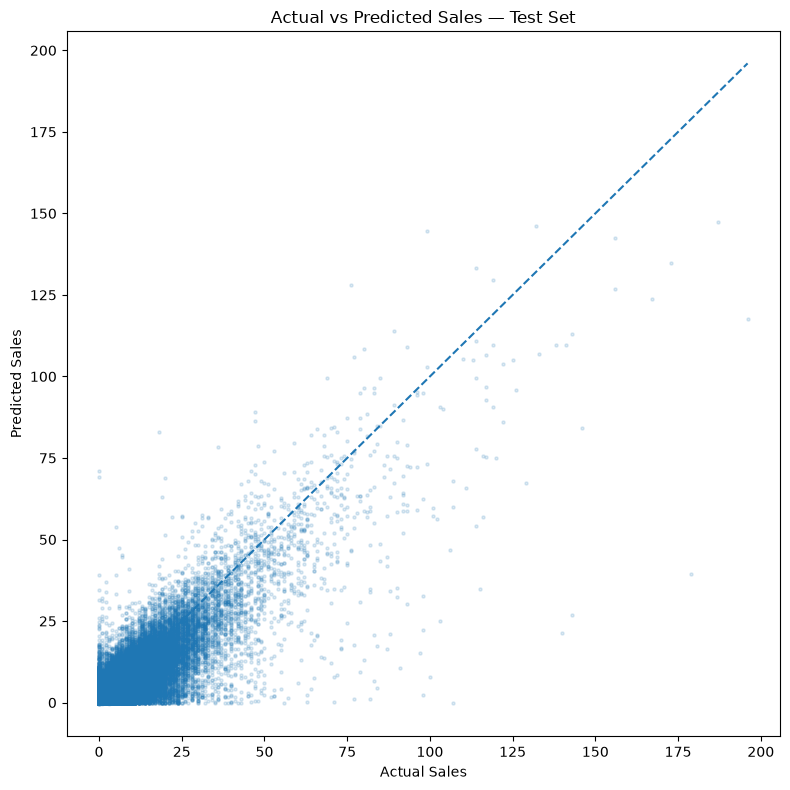

In [13]:
plt.figure(figsize=(8, 8))

plt.scatter(
    y_test,
    test_predictions,
    alpha=0.15,
    s=5
)

max_value = max(
    y_test.max(),
    test_predictions.max()
)

plt.plot(
    [0, max_value],
    [0, max_value],
    linestyle="--"
)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales — Test Set")

plt.tight_layout()
plt.show()

## 3. Where the model performs well

The dataset is highly sparse, so accurately handling the many low-demand observations matters. We therefore separate zero-demand and positive-demand cases rather than relying only on one overall score.

In [15]:
zero_mask_test = y_test == 0
positive_mask_test = y_test > 0

zero_mae_test = mean_absolute_error(
    y_test[zero_mask_test],
    test_predictions[zero_mask_test]
)

positive_mae_test = mean_absolute_error(
    y_test[positive_mask_test],
    test_predictions[positive_mask_test]
)

print("Zero-sales observations:", zero_mask_test.sum())
print("Positive-sales observations:", positive_mask_test.sum())

print("\nMAE by demand type")
print(f"Zero sales:     {zero_mae_test:.4f}")
print(f"Positive sales: {positive_mae_test:.4f}")

Zero-sales observations: 464725
Positive-sales observations: 388995

MAE by demand type
Zero sales:     0.2492
Positive sales: 1.6897


The model is particularly effective on the large number of low-demand observations. This is important in this dataset because zero-sales days are common. At the same time, positive-demand observations are inherently harder because there is much more variation in the size of the sale.

## 4. Where the model can improve

A useful evaluation should also reveal where the model is less reliable. We therefore examine error as actual demand increases.

In [14]:
error_analysis = pd.DataFrame({
    "actual": y_test.values,
    "prediction": test_predictions
})

error_analysis["absolute_error"] = (
    error_analysis["actual"] -
    error_analysis["prediction"]
).abs()

bins = [-1, 0, 1, 5, 10, 20, 50, 100, np.inf]

labels = [
    "0",
    "1",
    "2-5",
    "6-10",
    "11-20",
    "21-50",
    "51-100",
    "100+"
]

error_analysis["sales_range"] = pd.cut(
    error_analysis["actual"],
    bins=bins,
    labels=labels
)

error_by_range = (
    error_analysis
    .groupby("sales_range", observed=False)["absolute_error"]
    .agg(
        count="count",
        MAE="mean"
    )
)

display(error_by_range)

,count,MAE
sales_range,,
0,464725,0.249190
1,170444,0.764444
2-5,169438,1.684549
6-10,31380,3.488467
11-20,12879,5.825778
21-50,4305,10.519639
51-100,500,19.544285
100+,49,41.254946


### Interpretation

The model's absolute error increases as demand becomes larger. This is expected in a demand series with a long tail: high-demand observations are relatively rare but can vary substantially from day to day.

In other words, the model is **strongest on typical low-to-moderate demand**, while unusually high-demand days remain the main source of larger errors. This is an important limitation to keep in mind, but it does not erase the substantial improvement over the naive baseline.

## 5. Does the model capture overall demand over time?

The next view aggregates all item-store forecasts by date. This is useful because it shows whether the model follows the overall movement of demand across the 28-day horizon.

In [16]:
test_results = pd.DataFrame({
    "date": sales_model.loc[test_mask, "date"].values,
    "actual": y_test.values,
    "predicted": test_predictions
})

daily_test = (
    test_results
    .groupby("date")[["actual", "predicted"]]
    .sum()
)

display(daily_test)

,actual,predicted
date,,
2016-04-25,38793,27284.777438
2016-04-26,35487,25607.265166
2016-04-27,34445,25101.212589
2016-04-28,34732,25069.889291
2016-04-29,42896,28060.112947
2016-04-30,50429,37537.637032
2016-05-01,53032,39013.724549
2016-05-02,43181,30366.318051
2016-05-03,44314,29819.463591


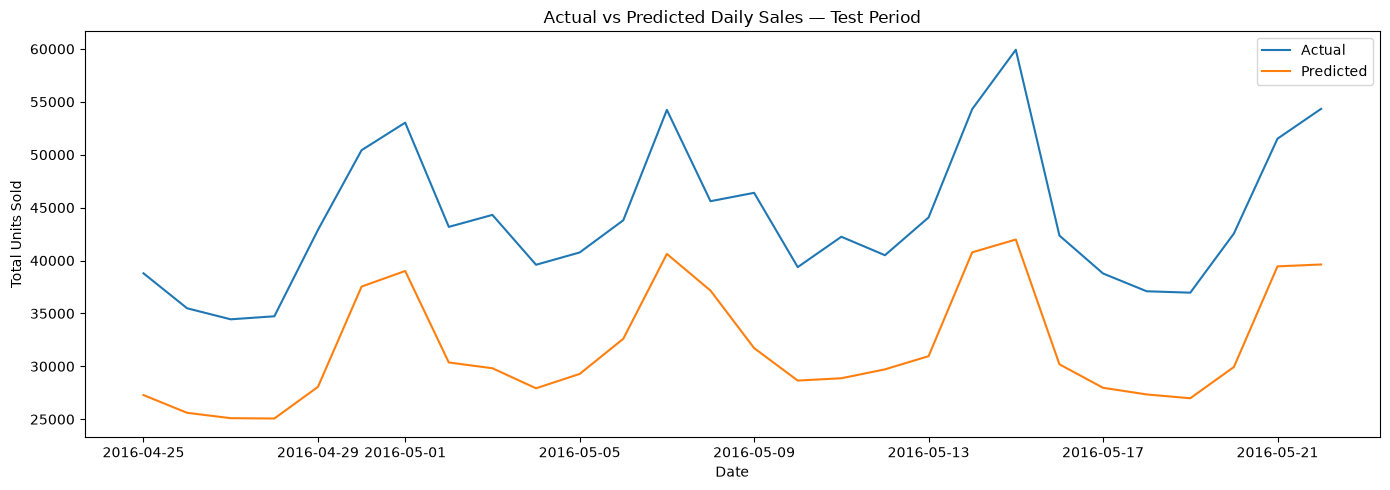

In [17]:
plt.figure(figsize=(14, 5))

plt.plot(
    daily_test.index,
    daily_test["actual"],
    label="Actual"
)

plt.plot(
    daily_test.index,
    daily_test["predicted"],
    label="Predicted"
)

plt.xlabel("Date")
plt.ylabel("Total Units Sold")
plt.title("Actual vs Predicted Daily Sales — Test Period")
plt.legend()

plt.tight_layout()
plt.show()

The model follows the overall day-to-day movement in demand, but the aggregate prediction is systematically conservative. Over the full test period, the model predicted approximately **72% of the total observed unit sales**.

This is consistent with the earlier error-by-demand analysis: the model handles the large number of low-demand observations well, but tends to underestimate the magnitude of higher-demand observations. We treat this as a clear area for future improvement rather than hiding it behind the overall MAE.

In [24]:
test_actual_total = y_test.sum()
test_predicted_total = test_predictions.sum()

test_bias_pct = (
    1 - test_predicted_total / test_actual_total
) * 100

print(f"Actual total sales:    {test_actual_total:,.0f}")
print(f"Predicted total sales: {test_predicted_total:,.0f}")
print(f"Underprediction:       {test_bias_pct:.2f}%")

Actual total sales:    1,231,764
Predicted total sales: 889,657
Underprediction:       27.77%


## 6. What features did the model rely on?

Feature importance is useful here as a high-level explanation of what the fitted model repeatedly found useful. The values below use LightGBM's **gain-based importance**, which measures how much a feature contributed to improving the model's splits.

In [18]:
feature_importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": model.booster_.feature_importance(
        importance_type="gain"
    )
}).sort_values(
    "importance",
    ascending=False
)

display(feature_importance)

,feature,importance
21,rolling_mean_14,2.328635e+08
22,rolling_mean_28,1.081747e+08
20,rolling_mean_7,4.773001e+07
0,item_id,2.115994e+07
14,lag_1,1.273772e+07
5,wday,1.103951e+07
1,dept_id,5.558607e+06
15,lag_2,3.391089e+06
10,event_name,3.140801e+06
18,lag_14,3.037144e+06


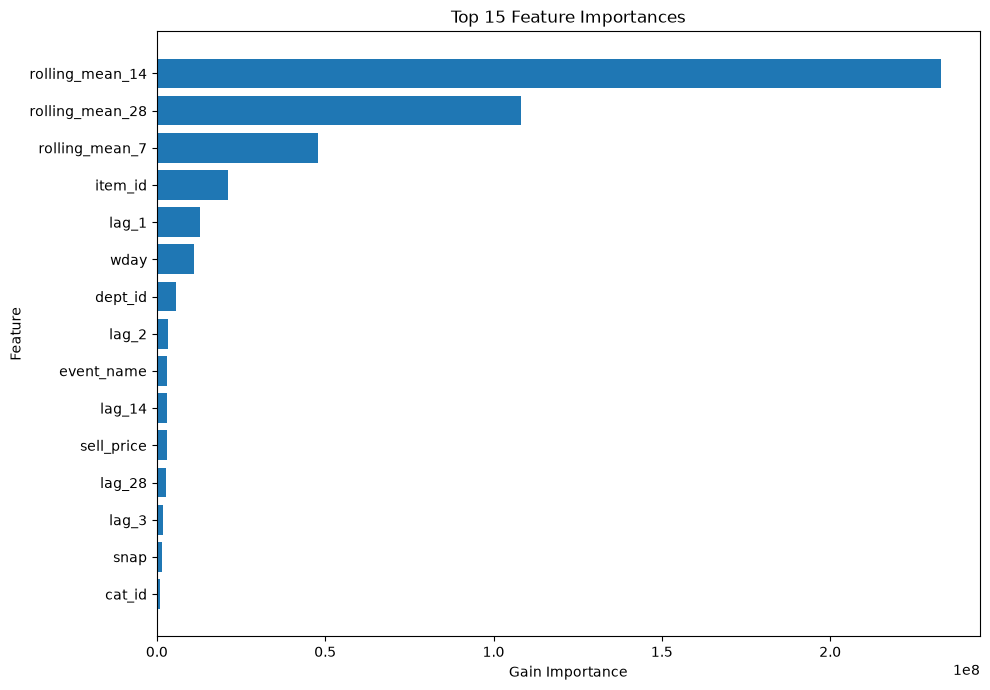

In [19]:
top_features = feature_importance.head(15).sort_values(
    "importance"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.xlabel("Gain Importance")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importances")

plt.tight_layout()
plt.show()

### Interpretation

The most influential features in the final model are dominated by **product identity and recent demand history**, with weekday and other contextual features providing additional information. This aligns well with the EDA: different products behave differently, and recent demand contains a strong signal about near-future demand.

## 7. Forecast in action

Aggregate metrics tell us whether the model works overall. The example below makes the prediction task more concrete by showing a few individual forecasts from the **unseen test period**.

These examples are illustrative and were not used for model selection.

In [ ]:
# Create a table of individual forecasts from the test set

forecast_examples = sales_model.loc[
    test_mask,
    [
        "item_id",
        "store_id",
        "date",
        "sales"
    ]
].copy()

forecast_examples["predicted_sales"] = test_predictions

forecast_examples["absolute_error"] = (
    forecast_examples["sales"] -
    forecast_examples["predicted_sales"]
).abs()

forecast_examples = forecast_examples.rename(
    columns={
        "sales": "actual_sales"
    }
)

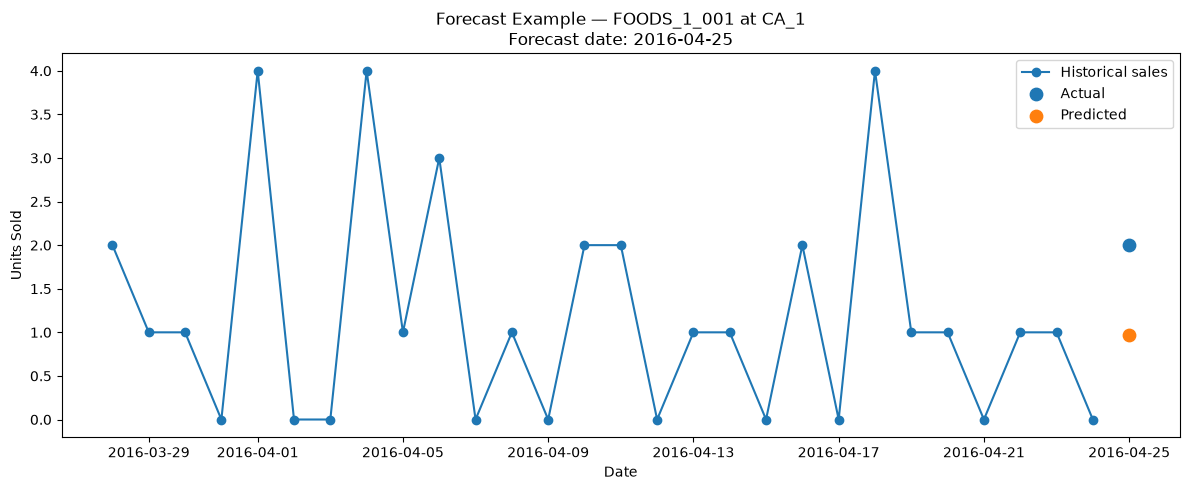

Item: FOODS_1_001
Store: CA_1
Forecast date: 2016-04-25
Predicted demand: 0.97 units
Actual demand: 2 units
Absolute error: 1.03 units


In [32]:
# Pick the first positive-sales observation in the test set
example_idx = forecast_examples[
    forecast_examples["actual_sales"] > 0
].index[0]

example_row = forecast_examples.loc[example_idx]

item = example_row["item_id"]
store = example_row["store_id"]
forecast_date = example_row["date"]

actual_value = example_row["actual_sales"]
predicted_value = example_row["predicted_sales"]

# Get the historical demand for this item-store pair
history = sales_model[
    (sales_model["item_id"] == item) &
    (sales_model["store_id"] == store) &
    (sales_model["date"] < forecast_date)
].sort_values("date").tail(28)

plt.figure(figsize=(12, 5))

plt.plot(
    history["date"],
    history["sales"],
    marker="o",
    label="Historical sales"
)

plt.scatter(
    forecast_date,
    actual_value,
    s=80,
    label="Actual"
)

plt.scatter(
    forecast_date,
    predicted_value,
    s=80,
    label="Predicted"
)

plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.title(
    f"Forecast Example — {item} at {store}\n"
    f"Forecast date: {forecast_date.date()}"
)

plt.legend()
plt.tight_layout()
plt.show()

print(f"Item: {item}")
print(f"Store: {store}")
print(f"Forecast date: {forecast_date.date()}")
print(f"Predicted demand: {predicted_value:.2f} units")
print(f"Actual demand: {actual_value:.0f} units")
print(f"Absolute error: {abs(actual_value - predicted_value):.2f} units")

In [35]:
# 1. Best positive-demand predictions
best_positive = (
    forecast_examples[
        forecast_examples["actual_sales"] > 0
    ]
    .sort_values("absolute_error")
    .head(3)
)

# 2. Representative moderate-demand predictions
moderate = (
    forecast_examples[
        (forecast_examples["actual_sales"] >= 5) &
        (forecast_examples["actual_sales"] <= 30)
    ]
    .sort_values("absolute_error")
    .head(3)
)

# 3. Largest errors on positive-demand observations
worst_positive = (
    forecast_examples[
        forecast_examples["actual_sales"] > 0
    ]
    .sort_values("absolute_error", ascending=False)
    .head(3)
)

print("BEST POSITIVE-DEMAND PREDICTIONS")
display(best_positive)

print("\nREPRESENTATIVE MODERATE-DEMAND PREDICTIONS")
display(moderate)

print("\nLARGEST POSITIVE-DEMAND ERRORS")
display(worst_positive)

BEST POSITIVE-DEMAND PREDICTIONS


,item_id,store_id,date,actual_sales,predicted_sales,absolute_error,error
32520986,HOBBIES_1_270,WI_3,2016-05-09,1,0.999996,0.000004,-0.000004
24631779,FOODS_3_675,TX_2,2016-05-14,1,1.000005,0.000005,0.000005
21905735,FOODS_3_533,CA_1,2016-04-25,1,0.999995,0.000005,-0.000005



REPRESENTATIVE MODERATE-DEMAND PREDICTIONS


,item_id,store_id,date,actual_sales,predicted_sales,absolute_error,error
43991338,HOUSEHOLD_1_304,TX_2,2016-05-13,5,5.000084,0.000084,0.000084
17364298,FOODS_3_295,TX_3,2016-05-20,7,6.999877,0.000123,-0.000123
1807763,FOODS_1_096,TX_1,2016-05-01,7,7.000326,0.000326,0.000326



LARGEST POSITIVE-DEMAND ERRORS


,item_id,store_id,date,actual_sales,predicted_sales,absolute_error,error
18917640,FOODS_3_376,WI_2,2016-05-06,179,39.277782,139.722218,-139.722218
13448374,FOODS_3_090,WI_3,2016-05-07,140,21.349340,118.650660,-118.650660
16201177,FOODS_3_234,WI_2,2016-05-03,143,26.933818,116.066182,-116.066182


## Final assessment

### Strengths

- The final LightGBM model improves **MAE by roughly 24%** over the lag-1 baseline on the unseen test period.
- It handles the dataset's many zero- and low-demand observations well.
- It captures the overall temporal pattern of sales rather than simply repeating the previous day's value.
- Feature importance shows that the model is using sensible signals: product identity, recent demand history and calendar structure.

### Limitations

- Prediction error increases as actual demand becomes larger.
- The model is conservative on high-demand observations, producing a noticeable aggregate underprediction over the test horizon.
- A regression model can produce small negative values even though sales cannot be negative; these should be constrained when predictions are displayed in a production application.

### Conclusion

The model is a meaningful improvement over a simple time-series baseline and provides a practical starting point for an interactive demand-forecasting application. The evaluation also makes the remaining weakness clear: **better calibration of high-demand forecasts is the most promising direction for future improvement**.

## Handoff to the application

The trained model and feature list are saved under `models/` and can now be used by the Streamlit application. The application will turn the same forecasting logic into an interactive workflow where a user can choose an item/store context and view predicted demand.